# <img src="image.png" alt="Credit Risk Model Optimization Logo" height="100" style="vertical-align: middle; margin-centre: 80px;" /> Credit Risk Model Optimization

## Overview
### The Story of Our Credit Transformation: From Rigid Rules to Holistic Risk Intelligence 
Every credit application tells a story, but for years, our underwriting system only read it one isolated sentence at a time. If an applicant’s debt-to-income ratio or dependent count crossed an unyielding, arbitrary line, the door was instantly shut. This rigid approach forced an artificial trade-off: we either took on toxic risk to grow our loan book, or we turned away thousands of creditworthy borrowers out of caution—leaving massive interest revenue on the table for our competitors.Our latest data optimization project rewrites this narrative. By transitioning from boosting models (XGBoost) to an optimized Random Forest Classifier, we have evolved our underwriting from a simple checklist into a system of holistic risk intelligence. Instead of looking at variables in a vacuum, our new engine reads the entire financial story dynamically, mapping how historical behaviors interact with current real-world capacity.The data revealed that an applicant’s financial resilience is overwhelmingly driven by an interconnected "Power Trio":
- The defensive gatekeeping of their riskscore
- The foundational capacity of their monthly income
- The structural leverage of their totalDebttoincome

Through the trees of our optimized model, these three features work in tandem with deeper behavioral and household markers. For instance, the engine recognizes that a single prior default dramatically compresses future repayment probability, regardless of current salary. Similarly, it automatically flags the precise tipping point where a high number of dependents places a silent, critical strain on baseline cash flow.The business implication is clear: We no longer have to guess where to draw the line. This model stabilizes our underwriting against severe data imbalances, dramatically squeezing out capital losses (False Positives) while safely capturing hidden, high-revenue opportunities (False Negatives).

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


## Credit Risk Model Optimization

In [41]:
# Imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, roc_auc_score

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier


In [2]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv("financial_loan_data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [3]:
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.duplicated()
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [5]:
df.LoanApproved.value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

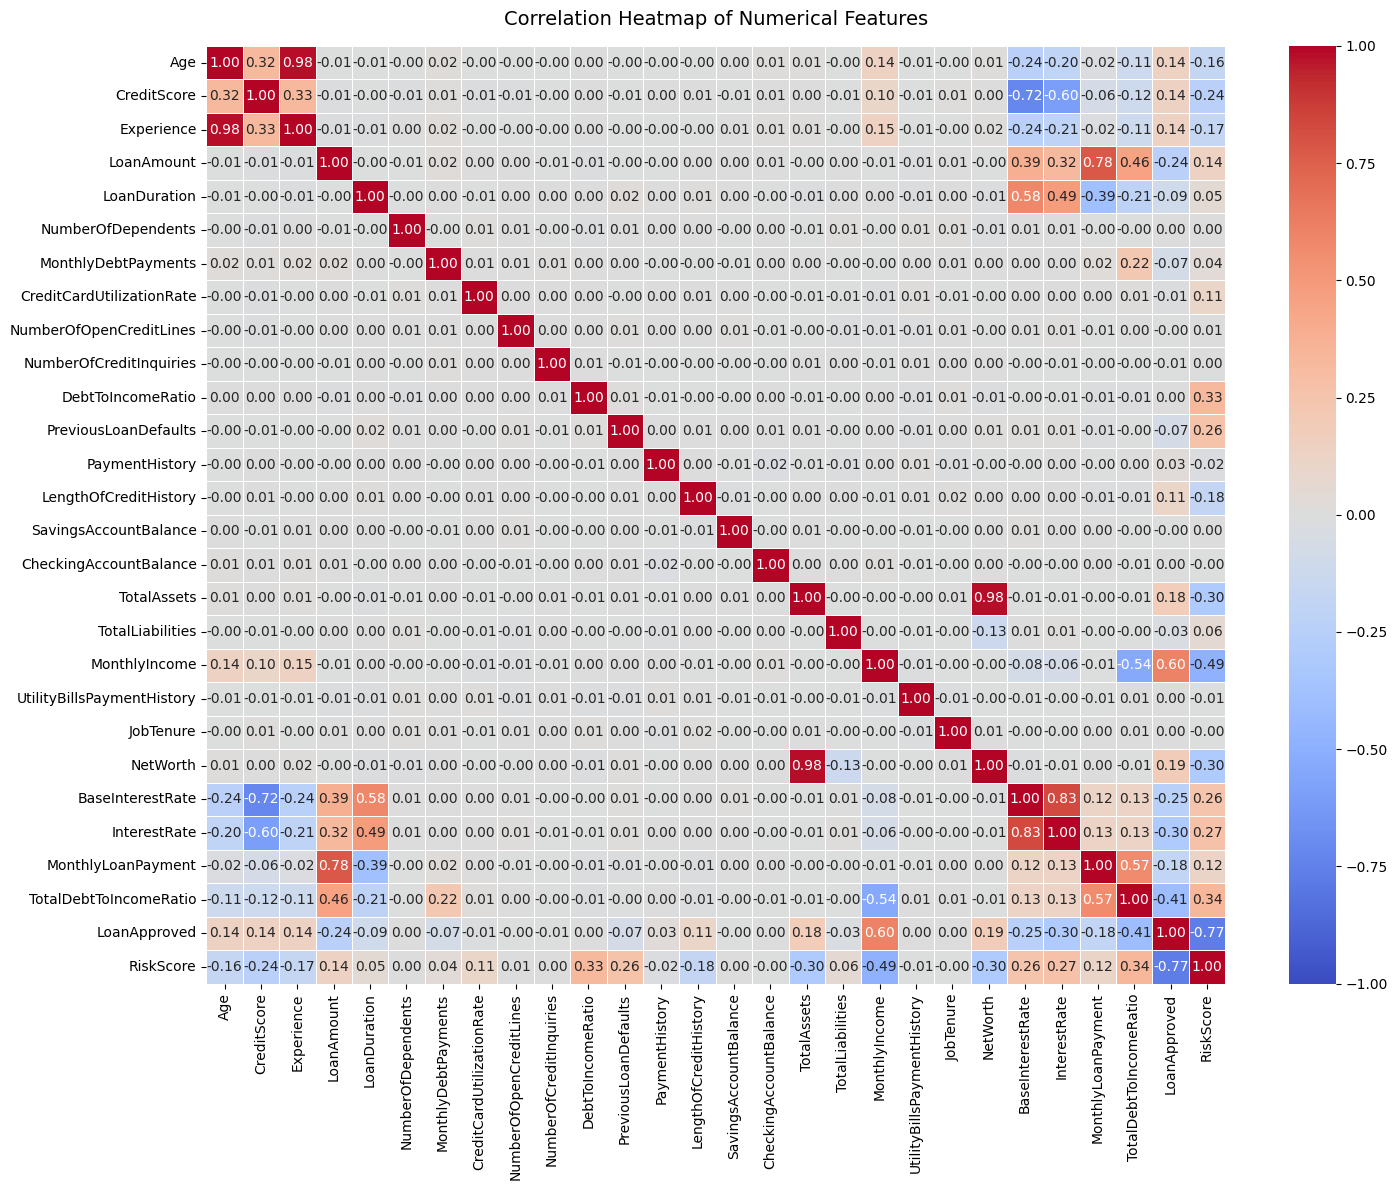

In [20]:
# 1. Filter out only numerical columns
numerical_df = df.select_dtypes(include=['number'])
# 2. Calculate the correlation matrix
correlation_matrix = numerical_df.corr()
# 3. Generate the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show correlation values inside the squares
    cmap='coolwarm',     # Color gradient (blue = negative, red = positive)
    fmt=".2f",           # Round values to 2 decimal places
    linewidths=0.5,      # Add a thin white border between cells
    vmin=-1, vmax=1      # Set colorbar limits to full correlation range
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

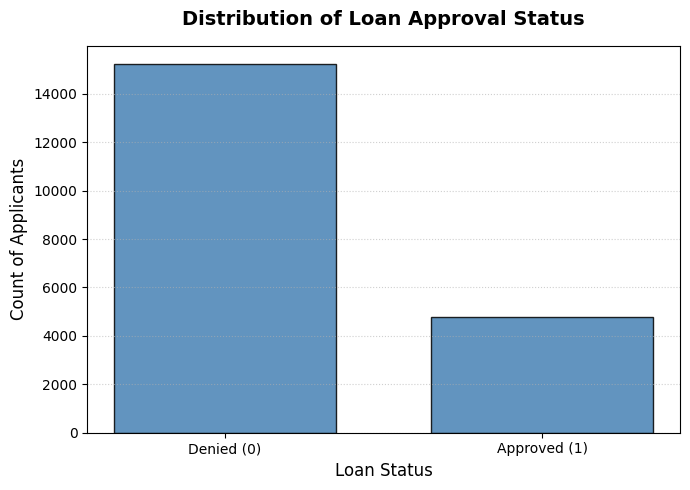

In [37]:
# 1. Initialize the plot layout
plt.figure(figsize=(7, 5))
# 2. Plot the histogram with explicit discrete bins centered on 0 and 1
# 'bins=[-0.5, 0.5, 1.5]' forces two separate bars for discrete binary data
plt.hist(
    df['LoanApproved'].astype(int), 
    bins=[-0.5, 0.5, 1.5], 
    rwidth=0.7, 
    color='steelblue', 
    edgecolor='black',
    alpha=0.85
)
# 3. Format axes and labels for scannability
plt.title('Distribution of Loan Approval Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count of Applicants', fontsize=12)
# Map numeric binary codes directly to readable business names on the X-axis
plt.xticks([0, 1], ['Denied (0)', 'Approved (1)'])
# Add visual gridlines behind the bars
plt.grid(axis='y', linestyle=':', alpha=0.6)
# 4. Display the chart
plt.tight_layout()
plt.show()

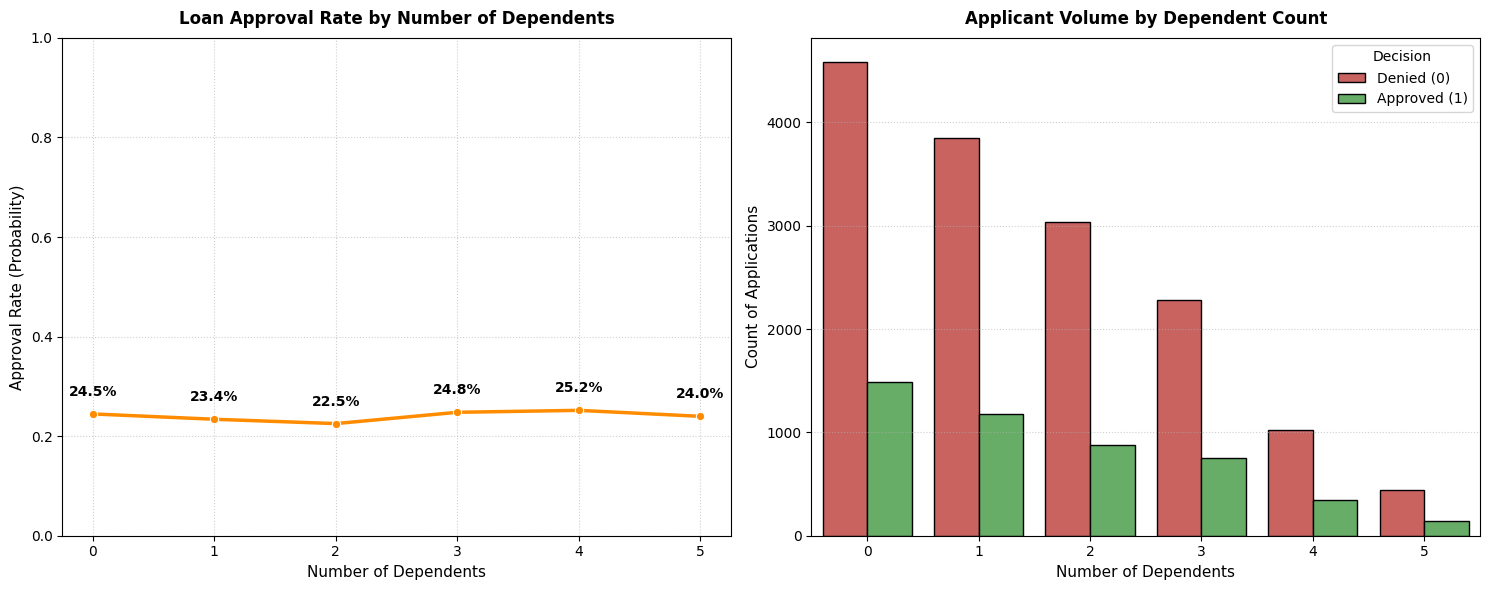

In [40]:
# 1. Initialize a clean, side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# --- PLOT 1: Loan Approval Rate Trend ---
# Calculate the mean approval rate for each dependent count (0, 1, 2, etc.)
approval_rates = df.groupby('NumberOfDependents')['LoanApproved'].mean().reset_index()
sns.lineplot(
    data=approval_rates, 
    x='NumberOfDependents', 
    y='LoanApproved', 
    marker='o', 
    linewidth=2.5, 
    color='darkorange', 
    ax=axes[0]
)
axes[0].set_title('Loan Approval Rate by Number of Dependents', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Dependents', fontsize=11)
axes[0].set_ylabel('Approval Rate (Probability)', fontsize=11)
axes[0].set_ylim(0, 1)  # Scale from 0% to 100%
axes[0].grid(True, linestyle=':', alpha=0.6)

# Annotate the exact percentages on the trend line points
for x, y in zip(approval_rates['NumberOfDependents'], approval_rates['LoanApproved']):
    axes[0].text(x, y + 0.03, f'{y:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
# --- PLOT 2: Applicant Volume Breakdown ---
sns.countplot(
    data=df, 
    x='NumberOfDependents', 
    hue='LoanApproved', 
    palette=['#d9534f', '#5cb85c'],  # Red for Denied, Green for Approved
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Applicant Volume by Dependent Count', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Number of Dependents', fontsize=11)
axes[1].set_ylabel('Count of Applications', fontsize=11)
axes[1].legend(['Denied (0)', 'Approved (1)'], title='Decision')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [6]:
# Data Prep Code Here - Create New Cells As Needed
X = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

In [7]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# Filtering the data. Separating the categorical columns and the numerical columns
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
print(categorical_cols)
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
print(numerical_cols)

['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']


In [9]:
# for the categorical columns, the missing values are first filled with the most_frequent within the column and then encoded using the OneHotEncoder
# for the numerical columns, the mission values are filled with the median and then scaled by StandardScaler 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

In [10]:
# Preprocessor: applies numeric and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [27]:
#  Modeling Code Here - Create New Cells as Needed
# Full pipeline with model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'  # Highly recommended for imbalanced loan data
    ))
])

# 2. Fit the pipeline (ensure y_train contains integer classes)
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [28]:
param_grid = {
    'classifier__max_depth':[50,100, 200], 
    'classifier__n_estimators':[100, 200 ], 
    'classifier__min_samples_split':[10,20,30,40,50],     
    'classifier__max_features': ['sqrt', 'log2']  
}
# 3. Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring='f1',   
    cv=5,
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)
# 4. Fit and clean data targets
grid_search.fit(X_train, y_train.astype(int))

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'classifier__max_depth': 200, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 30, 'classifier__n_estimators': 200}
Best CV F1-score: 0.9615799562192582


The choice of Random Forest Classifier for loan approval prediction is driven by its exceptional ability to manage binary classification tasks effectively within structured, highly imbalanced financial datasets. Loan approval decisions depend on intricate, interacting factors—such as income, credit history, marital status, and education level—and Random Forest excels at capturing these complex, non-linear relationships without the risk of severe overfitting often seen in boosting methods

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [ ]:
# Extract your optimal Random Forest model pipeline
final_model = grid_search.best_estimator_
# Run predictions on your holdout test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
# --- PART A: Assess Test Data Performance ---
print("=== RANDOM FOREST TEST PERFORMANCE ===")
# Force y_test to integers to avoid metric mismatches
print(classification_report(y_test.astype(int), y_pred, target_names=['Approved', 'Default']))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test.astype(int), y_proba):.4f}\n")


=== RANDOM FOREST TEST PERFORMANCE ===
              precision    recall  f1-score   support

    Approved       0.99      0.99      0.99      3044
     Default       0.96      0.96      0.96       956

    accuracy                           0.98      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.98      0.98      0.98      4000

Final Test ROC-AUC Score: 0.9970

=== SEGMENT PERFORMANCE ANALYSIS ===


c:\Users\Sadaam\anaconda3\envs\learn-env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


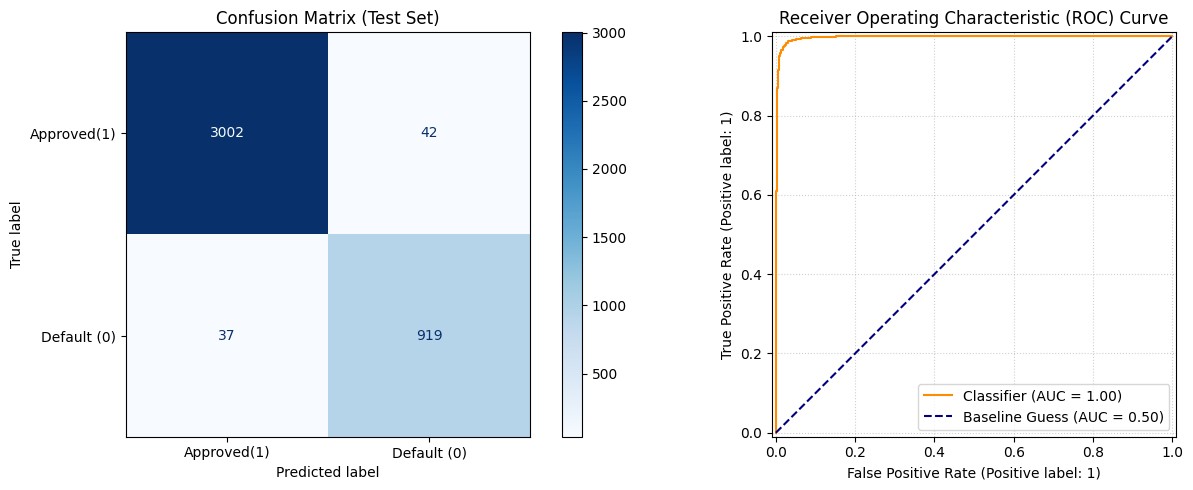

In [34]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
# 1. Create the side-by-side plot layout (axes is an array of 2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Confusion Matrix -> Assign explicitly to axes[0]
cm = confusion_matrix(y_test.astype(int), y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Approved(1)', 'Default (0)'])
cm_display.plot(ax=axes[0], cmap='Blues', values_format='d')  # Fixed indexing here
axes[0].set_title('Confusion Matrix (Test Set)')
axes[0].grid(False) # Clear gridlines over the matrix for visual cleanliness
# Plot 2: ROC-AUC Curve -> Assign explicitly to axes[1]
roc_display = RocCurveDisplay.from_predictions(y_test.astype(int), y_proba, ax=axes[1], color='darkorange') # Fixed indexing here
# Added the explicit x and y coordinates for the diagonal baseline
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline Guess (AUC = 0.50)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


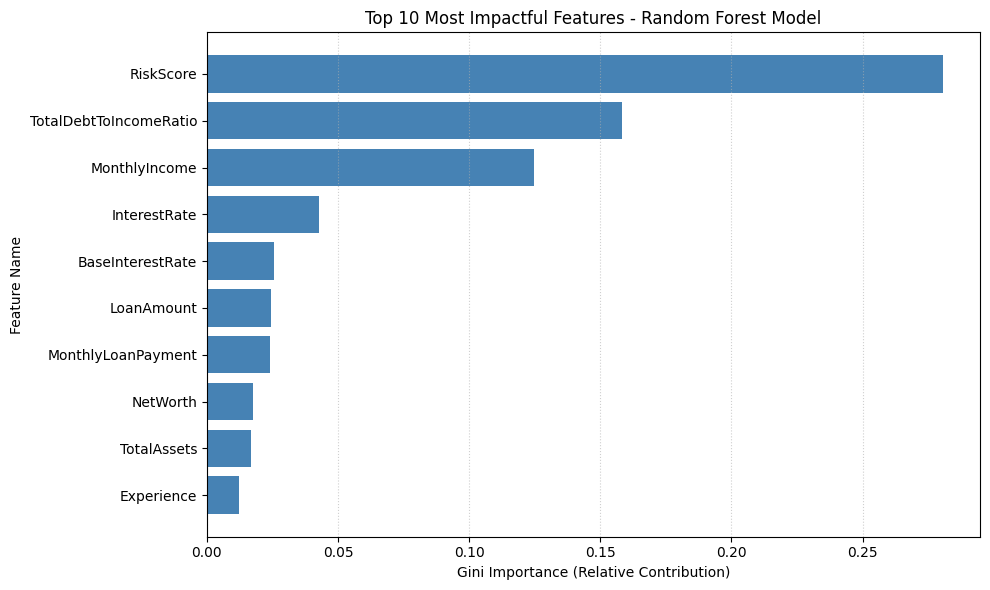

TOP 5 FEATURE IMPORTANCES
               Feature  Importance
             RiskScore    0.280719
TotalDebtToIncomeRatio    0.158234
         MonthlyIncome    0.124780
          InterestRate    0.042926
      BaseInterestRate    0.025567


In [36]:
# 1. Retrieve the fitted preprocessor and classifier from your best estimator
best_pipeline = grid_search.best_estimator_
preprocessor = best_pipeline.named_steps['preprocessor']
classifier = best_pipeline.named_steps['classifier']
# 2. Safely extract feature names generated by your preprocessor transforms
# (Works with scikit-learn 1.0+)
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback if get_feature_names_out isn't supported by a custom transformer
    feature_names = X_train.columns

# 3. Pair names with importances and create a structured DataFrame
importances = classifier.feature_importances_
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Clean up names for presentation (removes pipeline step prefixes like 'num__')
df_importance['Feature'] = df_importance['Feature'].str.split('__').str[-1]

# 5. Plot the Top 10 most impactful features
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'].head(10)[::-1], df_importance['Importance'].head(10)[::-1], color='steelblue')
plt.xlabel('Gini Importance (Relative Contribution)')
plt.ylabel('Feature Name')
plt.title('Top 10 Most Impactful Features - Random Forest Model')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the top features as text for documentation
print("TOP 5 FEATURE IMPORTANCES" )
print(df_importance.head(5).to_string(index=False))


> Yea it does lead to Potential Business Recommendation 